# Installing the required libraries:

In [57]:
%pip install datasets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Dataset loading:

**Loading the dataset and splitting them into train, test and validation:**

In [58]:
from datasets import load_dataset, load_metric
dataset = load_dataset("surrey-nlp/PLOD-CW")

In [59]:
train_dataset = dataset["train"]
val_dataset = dataset["validation"]
test_dataset = dataset["test"]

In [60]:
train_dataset[3:4]

{'tokens': [['EPI', '=', 'Echo', 'planar', 'imaging', '.']],
 'pos_tags': [['PROPN', 'PUNCT', 'NOUN', 'NOUN', 'NOUN', 'PUNCT']],
 'ner_tags': [['B-AC', 'B-O', 'B-LF', 'I-LF', 'I-LF', 'B-O']]}

In [61]:
X_train_data = [' '.join(sublist) for sublist in train_dataset['tokens']]
X_test_data = [' '.join(sublist) for sublist in test_dataset['tokens']]
X_val_data = [' '.join(sublist) for sublist in val_dataset['tokens']]

**Encoding the 'ner_tags':**

In [62]:
y_train_labels = train_dataset['ner_tags']
y_test_labels = test_dataset['ner_tags']
y_val_labels = val_dataset['ner_tags']

In [63]:
from sklearn.preprocessing import MultiLabelBinarizer

y_train_labels = train_dataset['ner_tags']
y_test_labels = test_dataset['ner_tags']
y_val_labels = val_dataset['ner_tags']

y_train_label_list = y_train_labels
y_test_label_list = y_test_labels
y_val_label_list = y_val_labels


encoder = MultiLabelBinarizer()

y_train = encoder.fit_transform(y_train_label_list)
y_test = encoder.fit_transform(y_test_label_list)
y_val = encoder.fit_transform(y_val_label_list)

# Word2vec RNN:

**Installing the required libraries:**

In [64]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
import gensim.downloader as api

**Loading the pre-trained word2vec model:**

In [65]:
word2vec_model = api.load('word2vec-google-news-300')

**Tokenization:**

In [66]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_data)
X_train_sequence = tokenizer.texts_to_sequences(X_train_data)
X_test_sequence = tokenizer.texts_to_sequences(X_test_data)
X_val_sequence = tokenizer.texts_to_sequences(X_val_data)

**Padding:**

In [67]:
max_seq_len = 323
X_train_pad = pad_sequences(X_train_sequence, maxlen=max_seq_len)
X_test_pad = pad_sequences(X_test_sequence, maxlen=max_seq_len)
X_val_pad = pad_sequences(X_val_sequence, maxlen=max_seq_len)

**Word2vec embedding:**

In [68]:
import numpy as np
vocab_size= len(tokenizer.word_index) +1
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
  if word in word2vec_model:
    embedding_matrix[i] = word2vec_model[word]

**Base Model(Optimizer - Adam, Loss Function - CrossEntropyLoss):**

In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
from gensim.models import KeyedVectors
from sklearn.metrics import classification_report
from datasets import load_dataset
from torch.utils.data import TensorDataset

# Load the dataset
dataset = load_dataset("surrey-nlp/PLOD-CW")
train_dataset = dataset['train']
validation_dataset = dataset['validation']
test_dataset = dataset['test']

# Define label encoding
label_encoding = {"B-O": 0, "B-AC": 1, "B-LF": 2, "I-LF": 3}

# Corrected function for preparing data
def prepare_data(dataset, word2vec_model, label_encoding, max_len=128):
    input_vectors = []
    labels = []
    
    for data in dataset:
        tokens = data['tokens']
        ner_tags = data['ner_tags']
        
        # Convert tokens to word vectors
        word_vectors = []
        for token in tokens:
            if token in word2vec_model:
                word_vectors.append(word2vec_model[token])
            else:
                # Handle out-of-vocabulary words
                word_vectors.append(np.zeros(word2vec_model.vector_size))
        
        # Pad or truncate word vectors to max_len
        if len(word_vectors) > max_len:
            word_vectors = word_vectors[:max_len]
        else:
            pad_length = max_len - len(word_vectors)
            word_vectors.extend([np.zeros(word2vec_model.vector_size)] * pad_length)
        
        input_vectors.append(np.array(word_vectors))  # Convert to numpy array
        
        # Convert NER tags to numerical labels, padding or truncating to max_len
        numerical_tags = [label_encoding.get(tag, -1) for tag in ner_tags]
        if len(numerical_tags) > max_len:
            numerical_tags = numerical_tags[:max_len]
        else:
            numerical_tags += [-1] * (max_len - len(numerical_tags))  
        
        labels.append(torch.tensor(numerical_tags))
    
    # Convert lists to tensors
    input_vectors = torch.tensor(input_vectors, dtype=torch.float32) 
    labels = torch.stack(labels)
    
    return TensorDataset(input_vectors, labels) 


train_data = prepare_data(train_dataset, word2vec_model, label_encoding)
validation_data = prepare_data(validation_dataset, word2vec_model, label_encoding)
test_data = prepare_data(test_dataset, word2vec_model, label_encoding)

# Create DataLoaders
train_loader = data.DataLoader(train_data, batch_size=16, shuffle=True)
validation_loader = data.DataLoader(validation_data, batch_size=16, shuffle=False)
test_loader = data.DataLoader(test_data, batch_size=16, shuffle=False)

class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_dim, output_dim, n_layers=1, dropout=0.3):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, input_vectors):
        # Pass through RNN
        rnn_out, _ = self.rnn(input_vectors)
        
        # Final classification
        output = self.fc(rnn_out)
        
        return output

# Model parameters
input_size = word2vec_model.vector_size  # Size of word vectors
hidden_dim = 128  
output_dim = len(label_encoding)  # Number of unique labels

# Create the model
model = RNNModel(input_size, hidden_dim, output_dim)

# Define the loss function with ignore_index
criterion = nn.CrossEntropyLoss(ignore_index=-1)
optimizer = optim.Adam(model.parameters(), lr=0.001) 

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for input_vectors, labels in train_loader:
        optimizer.zero_grad()  
        
        outputs = model(input_vectors)  
        
        # Flatten for loss computation
        logits_flat = outputs.view(-1, outputs.shape[-1])
        labels_flat = labels.view(-1)
        
        # Calculate loss, ignoring padding tokens
        loss = criterion(logits_flat, labels_flat)
        loss.backward()  
        optimizer.step()  
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

# Evaluation
model.eval()
predictions = []
ground_truth = []

with torch.no_grad():
    for input_vectors, labels in test_loader:
        outputs = model(input_vectors)  
        preds = torch.argmax(outputs, dim=-1) 
        
        # Store predictions and ground truth, converting them to numpy arrays
        predictions.append(preds.cpu().numpy())
        ground_truth.append(labels.cpu().numpy())

# Flatten the arrays for evaluation and concatenate all predictions/labels
flat_predictions = np.concatenate([arr.flatten() for arr in predictions])
flat_ground_truth = np.concatenate([arr.flatten() for arr in ground_truth])

# Remove instances where the label is -1 (padding/ignored)
valid_indices = flat_ground_truth != -1  
filtered_predictions = flat_predictions[valid_indices]  
filtered_ground_truth = flat_ground_truth[valid_indices]  

# Generate the classification report using only valid data
print(classification_report(
    filtered_ground_truth,
    filtered_predictions,
    zero_division=0  
))


/user/HS402/jj01056/.local/lib/python3.10/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch 1, Loss: 45.0995
Epoch 2, Loss: 33.0932
Epoch 3, Loss: 29.7448
Epoch 4, Loss: 27.9368
Epoch 5, Loss: 27.3153
Epoch 6, Loss: 25.9321
Epoch 7, Loss: 25.2714
Epoch 8, Loss: 25.0070
Epoch 9, Loss: 24.0080
Epoch 10, Loss: 23.4925
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      4292
           1       0.78      0.51      0.62       270
           2       0.31      0.12      0.17       150
           3       0.47      0.23      0.31       288

    accuracy                           0.88      5000
   macro avg       0.61      0.46      0.51      5000
weighted avg       0.85      0.88      0.86      5000



**Evaluation Metrics:**

In [70]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


conf_matrix = confusion_matrix(filtered_ground_truth, filtered_predictions)


accuracy = accuracy_score(filtered_ground_truth, filtered_predictions)


precision = precision_score(filtered_ground_truth, filtered_predictions, average='weighted')


recall = recall_score(filtered_ground_truth, filtered_predictions, average='weighted')


f1 = f1_score(filtered_ground_truth, filtered_predictions, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.875
Precision: 0.8491216852874368
Recall: 0.875
F1 Score: 0.8557222225819594


**Confusion matrix:**

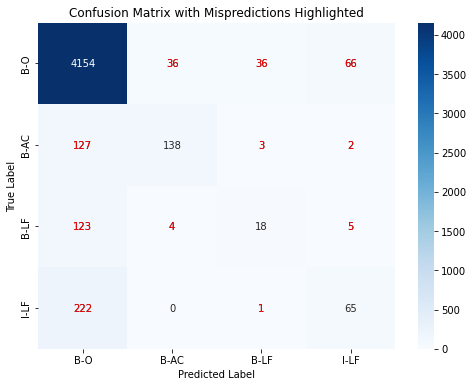

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=label_encoding.keys(), yticklabels=label_encoding.keys())

# Highlight mispredicted values in red
for i in range(len(label_encoding)):
    for j in range(len(label_encoding)):
        if i != j and conf_matrix[i, j] > 0:
            plt.text(j + 0.5, i + 0.5, conf_matrix[i, j], color='red', ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Mispredictions Highlighted")
plt.show()


<Axes: title={'center': 'Count of Actual and Predicted Labels'}, xlabel='Labels', ylabel='Count'>

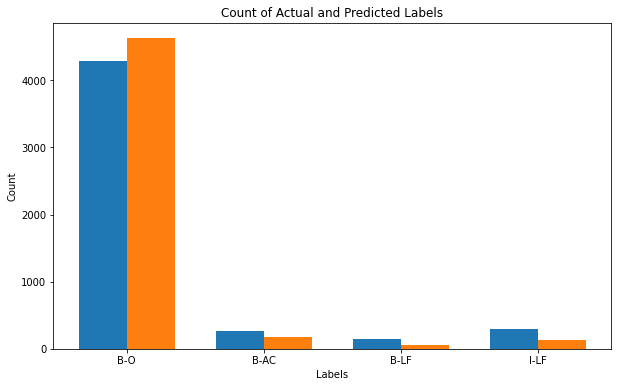

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten the arrays for evaluation and concatenate all predictions/labels
flat_predictions = np.concatenate([arr.flatten() for arr in predictions])
flat_ground_truth = np.concatenate([arr.flatten() for arr in ground_truth])

# Remove instances where the label is -1 (padding/ignored)
valid_indices = flat_ground_truth != -1  # Indices for valid labels (non-padding)
filtered_predictions = flat_predictions[valid_indices]  # Filtered predictions
filtered_ground_truth = flat_ground_truth[valid_indices]  # Filtered ground truth

# Define label names
label_names = list(label_encoding.keys())

# Define actual label names
actual_label_names = ['B-O', 'B-AC', 'B-LF', 'I-LF']

# Count of actual labels for each unique label
actual_label_count = {label: list(filtered_ground_truth).count(label_encoding[label]) for label in label_names}

# Count of predicted labels for each unique label
predicted_label_count = {label: list(filtered_predictions).count(label_encoding[label]) for label in label_names}

# Plot the counts
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = np.arange(len(label_names))

actual_bars = ax.bar(index, actual_label_count.values(), bar_width, label='Actual Labels')
predicted_bars = ax.bar(index + bar_width, predicted_label_count.values(), bar_width, label='Predicted Labels')

ax.set_xlabel('Labels')
ax.set_ylabel('Count')
ax.set_title('Count of Actual and Predicted Labels')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(actual_label_names)  # Set actual label names as tick labels
ax

**O-1(Optimizer - Adadelta, Loss Function - CrossEntropyLoss):**

In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
from sklearn.metrics import classification_report
from datasets import load_dataset
from torch.utils.data import TensorDataset

# Define model
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_dim, output_dim, n_layers=1, dropout=0.3):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, input_vectors):
        rnn_out, _ = self.rnn(input_vectors)
        output = self.fc(rnn_out)
        
        return output

# Load dataset
dataset = load_dataset("surrey-nlp/PLOD-CW")
train_dataset = dataset['train']
validation_dataset = dataset['validation']
test_dataset = dataset['test']

# Define label encoding
label_encoding = {"B-O": 0, "B-AC": 1, "B-LF": 2, "I-LF": 3}


def prepare_data(dataset, word2vec_model, label_encoding, max_len=128):
    input_vectors = []
    labels = []
    
    for data in dataset:
        tokens = data['tokens']
        ner_tags = data['ner_tags']
        
        # Convert tokens to word vectors
        word_vectors = []
        for token in tokens:
            if token in word2vec_model:
                word_vectors.append(word2vec_model[token])
            else:
                # Handle out-of-vocabulary words
                word_vectors.append(np.zeros(word2vec_model.vector_size))
        
        # Pad or truncate word vectors to max_len
        if len(word_vectors) > max_len:
            word_vectors = word_vectors[:max_len]
        else:
            pad_length = max_len - len(word_vectors)
            word_vectors.extend([np.zeros(word2vec_model.vector_size)] * pad_length)
        
        input_vectors.append(np.array(word_vectors)) 
        
        # Convert NER tags to numerical labels, padding or truncating to max_len
        numerical_tags = [label_encoding.get(tag, -1) for tag in ner_tags]
        if len(numerical_tags) > max_len:
            numerical_tags = numerical_tags[:max_len] 
        else:
            numerical_tags += [-1] * (max_len - len(numerical_tags))  
        
        labels.append(torch.tensor(numerical_tags))
    
    # Convert lists to tensors
    input_vectors = torch.tensor(input_vectors, dtype=torch.float32)  
    labels = torch.stack(labels)
    
    return TensorDataset(input_vectors, labels) 

# Prepare datasets for training, validation, and testing
train_data = prepare_data(train_dataset, word2vec_model, label_encoding)
validation_data = prepare_data(validation_dataset, word2vec_model, label_encoding)
test_data = prepare_data(test_dataset, word2vec_model, label_encoding)

# Create DataLoaders
train_loader = data.DataLoader(train_data, batch_size=16, shuffle=True)
validation_loader = data.DataLoader(validation_data, batch_size=16, shuffle=False)
test_loader = data.DataLoader(test_data, batch_size=16, shuffle=False)

# Model parameters
input_size = word2vec_model.vector_size  # Size of word vectors
hidden_dim = 128  
output_dim = len(label_encoding)  # Number of unique labels

# Create the model
model = RNNModel(input_size, hidden_dim, output_dim)

# Define the loss function with ignore_index
criterion = nn.CrossEntropyLoss(ignore_index=-1)

# Define the optimizer
optimizer = optim.Adadelta(model.parameters())

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for input_vectors, labels in train_loader:
        optimizer.zero_grad() 
        
        outputs = model(input_vectors) 
        logits_flat = outputs.view(-1, outputs.shape[-1])
        labels_flat = labels.view(-1)
        loss = criterion(logits_flat, labels_flat)
        loss.backward() 
        optimizer.step()  
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

# Evaluation
model.eval()
predictions = []
ground_truth = []

with torch.no_grad():
    for input_vectors, labels in test_loader:
        outputs = model(input_vectors)  
        preds = torch.argmax(outputs, dim=-1)  
        predictions.append(preds.cpu().numpy())
        ground_truth.append(labels.cpu().numpy())

# Flatten the arrays for evaluation and concatenate all predictions/labels
flat_predictions = np.concatenate([arr.flatten() for arr in predictions])
flat_ground_truth = np.concatenate([arr.flatten() for arr in ground_truth])

# Remove instances where the label is -1 (padding/ignored)
valid_indices = flat_ground_truth != -1 
filtered_predictions = flat_predictions[valid_indices] 
filtered_ground_truth = flat_ground_truth[valid_indices]  

# Generate the classification report using only valid data
print(classification_report(
    filtered_ground_truth,
    filtered_predictions,
    zero_division=0  
))



/user/HS402/jj01056/.local/lib/python3.10/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch 1, Loss: 43.2154
Epoch 2, Loss: 33.4021
Epoch 3, Loss: 30.3196
Epoch 4, Loss: 28.4940
Epoch 5, Loss: 27.7195
Epoch 6, Loss: 27.2797
Epoch 7, Loss: 26.3379
Epoch 8, Loss: 25.9548
Epoch 9, Loss: 25.4535
Epoch 10, Loss: 25.0475
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      4292
           1       0.76      0.49      0.60       270
           2       0.39      0.11      0.17       150
           3       0.60      0.08      0.15       288

    accuracy                           0.88      5000
   macro avg       0.66      0.42      0.46      5000
weighted avg       0.85      0.88      0.85      5000



**Evaluation Metrics:**

In [74]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

conf_matrix = confusion_matrix(filtered_ground_truth, filtered_predictions)

accuracy = accuracy_score(filtered_ground_truth, filtered_predictions)

precision = precision_score(filtered_ground_truth, filtered_predictions, average='weighted')

recall = recall_score(filtered_ground_truth, filtered_predictions, average='weighted')

f1 = f1_score(filtered_ground_truth, filtered_predictions, average='weighted')

print(classification_report(filtered_ground_truth, filtered_predictions, zero_division=0))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


              precision    recall  f1-score   support

           0       0.89      0.98      0.93      4292
           1       0.76      0.49      0.60       270
           2       0.39      0.11      0.17       150
           3       0.60      0.08      0.15       288

    accuracy                           0.88      5000
   macro avg       0.66      0.42      0.46      5000
weighted avg       0.85      0.88      0.85      5000

Accuracy: 0.878
Precision: 0.8503712727011531
Recall: 0.878
F1 Score: 0.8468600208184813


**Confusion Matrix:**

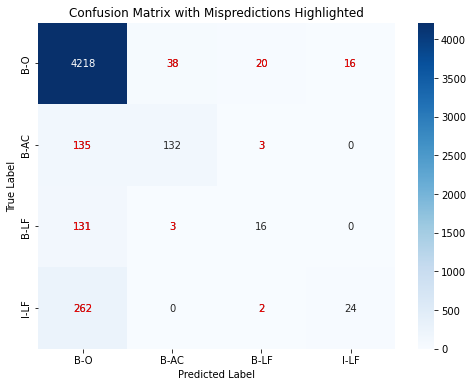

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=label_encoding.keys(), yticklabels=label_encoding.keys())

# Highlight mispredicted values in red
for i in range(len(label_encoding)):
    for j in range(len(label_encoding)):
        if i != j and conf_matrix[i, j] > 0:
            plt.text(j + 0.5, i + 0.5, conf_matrix[i, j], color='red', ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Mispredictions Highlighted")
plt.show()


**O-2(Optimizer - RMSprop, Loss Function - CrossEntropyLoss):**

In [76]:
# Model parameters
input_size = word2vec_model.vector_size  # Size of word vectors
hidden_dim = 128  # Adjust as needed
output_dim = len(label_encoding)  # Number of unique labels

# Create the model
model = RNNModel(input_size, hidden_dim, output_dim)

# Define the loss function with ignore_index
criterion = nn.CrossEntropyLoss(ignore_index=-1)  # CrossEntropyLoss
optimizer = optim.RMSprop(model.parameters(), lr=0.001)  # RMSprop optimizer

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for input_vectors, labels in train_loader:
        optimizer.zero_grad()  # Reset gradients
        
        outputs = model(input_vectors)  # Forward pass
        
        # Flatten for loss computation
        logits_flat = outputs.view(-1, outputs.shape[-1])
        labels_flat = labels.view(-1)
        
        # Calculate loss, ignoring padding tokens
        loss = criterion(logits_flat, labels_flat)
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

# Evaluation
model.eval()
predictions = []
ground_truth = []

with torch.no_grad():
    for input_vectors, labels in test_loader:
        outputs = model(input_vectors)
        preds = torch.argmax(outputs, dim=-1)  
        
        # Store predictions and ground truth, converting them to numpy arrays
        predictions.append(preds.cpu().numpy())
        ground_truth.append(labels.cpu().numpy())

# Flatten the arrays for evaluation and concatenate all predictions/labels
flat_predictions = np.concatenate([arr.flatten() for arr in predictions])
flat_ground_truth = np.concatenate([arr.flatten() for arr in ground_truth])

# Remove instances where the label is -1 (padding/ignored)
valid_indices = flat_ground_truth != -1  
filtered_predictions = flat_predictions[valid_indices]  
filtered_ground_truth = flat_ground_truth[valid_indices]  

# Generate the classification report using only valid data
print(classification_report(
    filtered_ground_truth,
    filtered_predictions,
    zero_division=0 
))


/user/HS402/jj01056/.local/lib/python3.10/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch 1, Loss: 36.9210
Epoch 2, Loss: 29.7777
Epoch 3, Loss: 27.8207
Epoch 4, Loss: 26.5884
Epoch 5, Loss: 25.8153
Epoch 6, Loss: 25.2294
Epoch 7, Loss: 24.4279
Epoch 8, Loss: 23.8542
Epoch 9, Loss: 23.5420
Epoch 10, Loss: 22.5472
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      4292
           1       0.78      0.53      0.63       270
           2       0.35      0.15      0.21       150
           3       0.44      0.24      0.31       288

    accuracy                           0.87      5000
   macro avg       0.62      0.47      0.52      5000
weighted avg       0.85      0.87      0.86      5000



**Evaluation Metrics:**

In [77]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

conf_matrix = confusion_matrix(filtered_ground_truth, filtered_predictions)

accuracy = accuracy_score(filtered_ground_truth, filtered_predictions)

precision = precision_score(filtered_ground_truth, filtered_predictions, average='weighted')

recall = recall_score(filtered_ground_truth, filtered_predictions, average='weighted')

f1 = f1_score(filtered_ground_truth, filtered_predictions, average='weighted')

print(classification_report(filtered_ground_truth, filtered_predictions, zero_division=0))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


              precision    recall  f1-score   support

           0       0.90      0.96      0.93      4292
           1       0.78      0.53      0.63       270
           2       0.35      0.15      0.21       150
           3       0.44      0.24      0.31       288

    accuracy                           0.87      5000
   macro avg       0.62      0.47      0.52      5000
weighted avg       0.85      0.87      0.86      5000

Accuracy: 0.8738
Precision: 0.8501793974519823
Recall: 0.8738
F1 Score: 0.8568682663650244


**Confusion Matrix:**

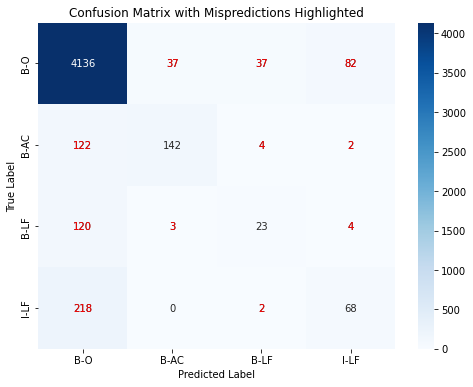

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=label_encoding.keys(), yticklabels=label_encoding.keys())

# Highlight mispredicted values in red
for i in range(len(label_encoding)):
    for j in range(len(label_encoding)):
        if i != j and conf_matrix[i, j] > 0:
            plt.text(j + 0.5, i + 0.5, conf_matrix[i, j], color='red', ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Mispredictions Highlighted")
plt.show()


**O-3(Optimizer - Adagrad, Loss Function - CrossEntropyLoss):**

In [79]:
# Model parameters
input_size = word2vec_model.vector_size  # Size of word vectors
hidden_dim = 128 
output_dim = len(label_encoding)  # Number of unique labels

# Create the model
model = RNNModel(input_size, hidden_dim, output_dim)

# Define the loss function with ignore_index
criterion = nn.CrossEntropyLoss(ignore_index=-1)

# Define the optimizer (using Adagrad)
optimizer = optim.Adagrad(model.parameters(), lr=0.01)

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for input_vectors, labels in train_loader:
        optimizer.zero_grad()  # Reset gradients
        
        outputs = model(input_vectors)  # Forward pass
        
        # Flatten for loss computation
        logits_flat = outputs.view(-1, outputs.shape[-1])
        labels_flat = labels.view(-1)
        
        # Calculate loss, ignoring padding tokens
        loss = criterion(logits_flat, labels_flat)
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch + 1}, Loss: {total_loss:.4f}")

# Evaluation
model.eval()
predictions = []
ground_truth = []

with torch.no_grad():
    for input_vectors, labels in test_loader:
        outputs = model(input_vectors)  
        preds = torch.argmax(outputs, dim=-1)  
        
        # Store predictions and ground truth, converting them to numpy arrays
        predictions.append(preds.cpu().numpy())
        ground_truth.append(labels.cpu().numpy())

# Flatten the arrays for evaluation and concatenate all predictions/labels
flat_predictions = np.concatenate([arr.flatten() for arr in predictions])
flat_ground_truth = np.concatenate([arr.flatten() for arr in ground_truth])

# Remove instances where the label is -1 (padding/ignored)
valid_indices = flat_ground_truth != -1  # Indices for valid labels (non-padding)
filtered_predictions = flat_predictions[valid_indices]  # Filtered predictions
filtered_ground_truth = flat_ground_truth[valid_indices]  # Filtered ground truth

# Generate the classification report using only valid data
print(classification_report(
    filtered_ground_truth,
    filtered_predictions,
    zero_division=0  
))


/user/HS402/jj01056/.local/lib/python3.10/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


Epoch 1, Loss: 36.8724
Epoch 2, Loss: 29.8432
Epoch 3, Loss: 28.1212
Epoch 4, Loss: 26.9824
Epoch 5, Loss: 26.1401
Epoch 6, Loss: 25.6141
Epoch 7, Loss: 25.0499
Epoch 8, Loss: 24.7270
Epoch 9, Loss: 24.1935
Epoch 10, Loss: 23.6021
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      4292
           1       0.79      0.51      0.62       270
           2       0.35      0.14      0.20       150
           3       0.46      0.22      0.29       288

    accuracy                           0.88      5000
   macro avg       0.62      0.46      0.51      5000
weighted avg       0.85      0.88      0.86      5000



**Evaluation Merics:**

In [80]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


conf_matrix = confusion_matrix(filtered_ground_truth, filtered_predictions)

accuracy = accuracy_score(filtered_ground_truth, filtered_predictions)

precision = precision_score(filtered_ground_truth, filtered_predictions, average='weighted')

recall = recall_score(filtered_ground_truth, filtered_predictions, average='weighted')

f1 = f1_score(filtered_ground_truth, filtered_predictions, average='weighted')

print(classification_report(filtered_ground_truth, filtered_predictions, zero_division=0))

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


              precision    recall  f1-score   support

           0       0.90      0.97      0.93      4292
           1       0.79      0.51      0.62       270
           2       0.35      0.14      0.20       150
           3       0.46      0.22      0.29       288

    accuracy                           0.88      5000
   macro avg       0.62      0.46      0.51      5000
weighted avg       0.85      0.88      0.86      5000

Accuracy: 0.8754
Precision: 0.8501026808264105
Recall: 0.8754
F1 Score: 0.8561524148901892


**Confusion Matrix:**

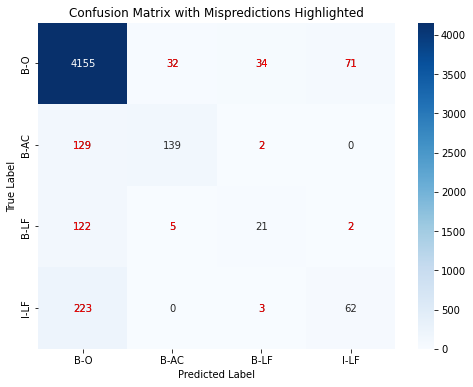

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=label_encoding.keys(), yticklabels=label_encoding.keys())

# Highlight mispredicted values in red
for i in range(len(label_encoding)):
    for j in range(len(label_encoding)):
        if i != j and conf_matrix[i, j] > 0:
            plt.text(j + 0.5, i + 0.5, conf_matrix[i, j], color='red', ha='center', va='center')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Mispredictions Highlighted")
plt.show()


In [82]:
print('Notebook executed successfully')

Notebook executed successfully
